In [1]:
from ucimlrepo import fetch_ucirepo
import random

obesity_repo = fetch_ucirepo(id=544)
random.seed(8167)

In [2]:
# print(repo.keys())
# print(repo.variables)
data = obesity_repo.data.features.to_numpy()
# print(data.shape)
# print(data[0,:])

string_variables = {}
for j in range(data.shape[1]):
    value = data[0,j]
    if type(value) == str:
        print(value)
        string_variables[j] = []

for i in range(data.shape[0]):
    value = data[i,:]
    for j in string_variables:
        if data[i,j] not in string_variables[j]:
            string_variables[j].append(data[i,j])
print(string_variables)

target_data = obesity_repo.data.targets.to_numpy()
target_values = []
for i in range(target_data.shape[0]):
    if target_data[i,0] not in target_values:
        target_values.append(target_data[i,0])
print(target_values)

Female
yes
no
Sometimes
no
no
no
Public_Transportation
{0: ['Female', 'Male'], 4: ['yes', 'no'], 5: ['no', 'yes'], 8: ['Sometimes', 'Frequently', 'Always', 'no'], 9: ['no', 'yes'], 11: ['no', 'yes'], 14: ['no', 'Sometimes', 'Frequently', 'Always'], 15: ['Public_Transportation', 'Walking', 'Automobile', 'Motorbike', 'Bike']}
['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 'Obesity_Type_I', 'Insufficient_Weight', 'Obesity_Type_II', 'Obesity_Type_III']


In [3]:
gender = {"Female": 0.0, "Male": 1.0}
binary = {"no": 0.0, "yes": 1.0}
frequency = {"no": 0.0, "Sometimes": 1.0, "Frequently": 2.0, "Always": 3.0}
transportation = {"Public_Transportation": 0.0, "Walking": 1.0, "Automobile": 2.0, "Motorbike": 3.0, "Bike": 4.0}

special_values = {0: gender, 4: binary, 5: binary, 8: frequency, 9: binary, 11: binary, 14: frequency, 15: transportation}

def preprocess_obesity(instance):
    return (*[special_values[i][instance[i]] if i in special_values else (float(instance[i]) if i != 3 else 0.0) for i in range(len(instance))],)

features = obesity_repo.data.features.to_numpy()
x_obesity = [preprocess_obesity(features[i,:]) for i in range(features.shape[0])]
print(x_obesity)

target_values = {"Insufficient_Weight": 0, "Normal_Weight": 1, "Overweight_Level_I": 2, "Overweight_Level_II": 3, "Obesity_Type_I": 4, "Obesity_Type_II": 5, "Obesity_Type_III": 6}

def preprocess_obesity_target(instance):
    target_output = [0.0] * len(target_values)
    target_class = target_values[instance.item()]
    target_output[target_class] = 1.0
    return target_output

targets = obesity_repo.data.targets.to_numpy()
y_obesity = [preprocess_obesity_target(targets[i,:]) for i in range(targets.shape[0])]
print(y_obesity)

[(0.0, 21.0, 1.62, 0.0, 1.0, 0.0, 2.0, 3.0, 1.0, 0.0, 2.0, 0.0, 0.0, 1.0, 0.0, 0.0), (0.0, 21.0, 1.52, 0.0, 1.0, 0.0, 3.0, 3.0, 1.0, 1.0, 3.0, 1.0, 3.0, 0.0, 1.0, 0.0), (1.0, 23.0, 1.8, 0.0, 1.0, 0.0, 2.0, 3.0, 1.0, 0.0, 2.0, 0.0, 2.0, 1.0, 2.0, 0.0), (1.0, 27.0, 1.8, 0.0, 0.0, 0.0, 3.0, 3.0, 1.0, 0.0, 2.0, 0.0, 2.0, 0.0, 2.0, 1.0), (1.0, 22.0, 1.78, 0.0, 0.0, 0.0, 2.0, 1.0, 1.0, 0.0, 2.0, 0.0, 0.0, 0.0, 1.0, 0.0), (1.0, 29.0, 1.62, 0.0, 0.0, 1.0, 2.0, 3.0, 1.0, 0.0, 2.0, 0.0, 0.0, 0.0, 1.0, 2.0), (0.0, 23.0, 1.5, 0.0, 1.0, 1.0, 3.0, 3.0, 1.0, 0.0, 2.0, 0.0, 1.0, 0.0, 1.0, 3.0), (1.0, 22.0, 1.64, 0.0, 0.0, 0.0, 2.0, 3.0, 1.0, 0.0, 2.0, 0.0, 3.0, 0.0, 1.0, 0.0), (1.0, 24.0, 1.78, 0.0, 1.0, 1.0, 3.0, 3.0, 1.0, 0.0, 2.0, 0.0, 1.0, 1.0, 2.0, 0.0), (1.0, 22.0, 1.72, 0.0, 1.0, 1.0, 2.0, 3.0, 1.0, 0.0, 2.0, 0.0, 1.0, 1.0, 0.0, 0.0), (1.0, 26.0, 1.85, 0.0, 1.0, 1.0, 3.0, 3.0, 2.0, 0.0, 3.0, 0.0, 2.0, 2.0, 1.0, 0.0), (0.0, 21.0, 1.72, 0.0, 1.0, 1.0, 2.0, 3.0, 2.0, 0.0, 2.0, 1.0, 2.0, 1.0, 1.0, 

In [4]:
def double_shuffle(x_data, y_data):
    if len(x_data) != len(y_data):
        raise ValueError("X and Y data must be the same size.")
    indices = [*range(len(x_data))]
    random.shuffle(indices)
    new_x_data = [x_data[indices[i]] for i in range(len(x_data))]
    new_y_data = [y_data[indices[i]] for i in range(len(x_data))]
    return new_x_data, new_y_data

def split_dataset(dataset, train_proportion):
    split = int(len(dataset) * train_proportion)
    train_data = dataset[:split]
    test_data = dataset[split:]
    return train_data, test_data

In [5]:
x_shuffled_obesity, y_shuffled_obesity = double_shuffle(x_obesity, y_obesity)

x_train_obesity, x_test_obesity = split_dataset(x_shuffled_obesity, 0.8)
y_train_obesity, y_test_obesity = split_dataset(y_shuffled_obesity, 0.8)

In [6]:
import random
import math
from crossover import *
from fitness import *
from initializers import *
from mutation import *
from operations import *
from population import *
from program import *
from selection import *

In [7]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

def plot_evolution(population, generation_count, stop_at_fitness):
    (generations, means, mins, all_time_best_fitness, all_time_best_program, all_custom_stats) = population.evolve(generation_count, stop_at_fitness)
    fig, ax = plt.subplots()
    ax.set_title(F"Best Fitness")
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fitness")
    ax.plot(generations, mins)
    plt.show()
    all_time_best_program.print_readable_code()
    return (generations, means, mins, all_time_best_fitness, all_time_best_program, all_custom_stats)

def plot_accuracy(generations, accuracy):
    plt.plot(generations, accuracy)
    plt.ylim([0.0,1.0])
    plt.xlabel("Generation")
    plt.ylabel("Accuracy")
    plt.title("Accuracy over Time")
    plt.show()

In [16]:
operations = [Addition, Subtraction, Multiplication, Division, Square, SquareRoot, Exponent, Logarithm, Conjunction, Disjunction, LogicalNegation, Conditional, Sine, Sigmoid, Conjunction, Disjunction, LogicalNegation]
fitness_func = mse_fitness_with_softmax(x_train_obesity, y_train_obesity)
selection_func = binary_tournament_selection
mutation_func = standard_mutation(operations, 0.25, 0.00)
program_mutation_rate = 1.0
crossover_rate = 0.1
instruction_count = 10
register_count = 4
input_value_count = len(x_train_obesity[0])
output_value_count = 7
register_initializer = RI_always_one
crossover_func=var_length_crossover()
survival_selection_func = binary_tournament_selection
lam = 1000
nu = 500
mu = 1000

def accuracy_stats(population):
    best_fitness_index = np.argmax([population._internal_fitness(member) for member in population.members])
    best_fitness_member = population.members[best_fitness_index]
    accuracy = -1 * classifier_accuracy_func_full(best_fitness_member, x_test_obesity, y_test_obesity, timeout=None)
    return accuracy


In [9]:
if False:
        pop = Population(lam, nu, mu, selection_func, mutation_func, program_mutation_rate, \
                crossover_rate, instruction_count, register_count, output_value_count, \
                operations, register_initializer, fitness_func, crossover_func, survival_selection_func, stats_gatherer=accuracy_stats, mu_plus_lambda=True)

        (generations, means, mins, all_time_best_fitness, all_time_best_program, all_custom_stats) = plot_evolution(pop, 10, 0.0)
        plot_accuracy(generations, all_custom_stats)

Beginning evolution.
Completed 1/10 generations. Best Fitness: 0.8401080460574841					

c:\Users\Patri\source\repos\LGP\fitness.py:38: RuntimeWarning: invalid value encountered in subtract
  y_hat = np.exp(y_hat - y_hat.max())


Completed 10/10 generations. Best Fitness: 0.8196109341477259					
Evolution complete.


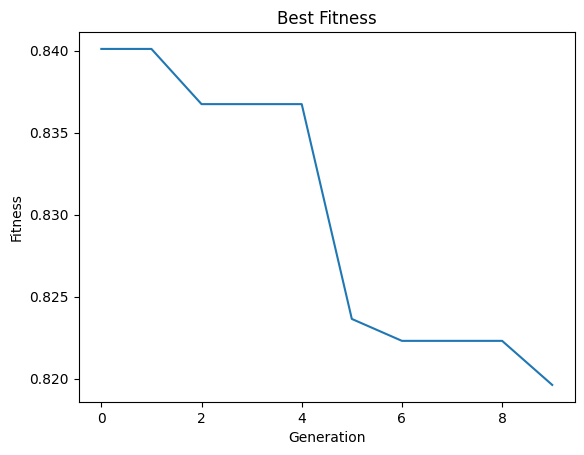

# Register Initialization
r0 = 0.9998563528060913
r1 = 1.0
r2 = 1.0
r3 = 1.0
r4 = 1.0
r5 = 1.000056505203247
r6 = 1.000085711479187
r7 = 1.0
r8 = 1.0
r9 = 1.0
# Start of Program
 1.  r9 = sigmoid(r-1)
 2.  r5 = sigmoid(r9)
 3.  r9 = not r-13
 4.  r9 = r6 / r-16
 5.  r1 = r6 and r-9
 6.  r7 = not r-14
 7.  r2 = sigmoid(r0)
 8.  r8 = not r-1
 9.  r6 = r-7 - r-9
10.  r7 = sin(r-13)
# End of Program


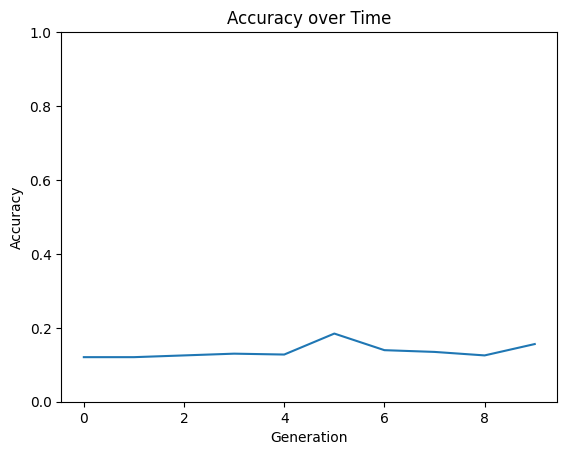

In [ ]:
gd_x_train_obesity = split_dataset(x_train_obesity, 0.1)[0]
gd_y_train_obesity = split_dataset(y_train_obesity, 0.1)[0]
gd_fitness_func = mse_tensor_fitness_with_softmax(gd_x_train_obesity, gd_y_train_obesity)

custom_mutation_func = combined_mutation(
    standard_mutation(operations, 0.3, 0.0),
    gradient_descent_mutation(0.25, 0.01, 4, gd_fitness_func)
)

fitness_func = classifier_accuracy(x_train_obesity, y_train_obesity)

pop = Population(lam, nu, mu, selection_func, custom_mutation_func, program_mutation_rate, \
    crossover_rate, instruction_count, register_count, input_value_count, output_value_count, \
    operations, register_initializer, fitness_func, crossover_func, survival_selection_func, stats_gatherer=accuracy_stats, mu_plus_lambda=True)

(generations, means, mins, all_time_best_fitness, all_time_best_program, all_custom_stats) = plot_evolution(pop, 10, -math.inf)
plot_accuracy(generations, all_custom_stats)

In [15]:
print(all_custom_stats)

[0.12056737588652482, 0.12056737588652482, 0.12529550827423167, 0.13002364066193853, 0.1276595744680851, 0.18439716312056736, 0.13947990543735225, 0.1347517730496454, 0.12529550827423167, 0.15602836879432624]
